In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({'figure.dpi': 120, 'font.size': 12})

In [12]:
PARQUET = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/combined/"
    "IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1_fluxlessweight/"
    "dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1_fluxlessweight.parquet"
)

df = pd.read_parquet(PARQUET)
print(f"Loaded {len(df):,} events, {df.shape[1]} columns")

Loaded 698,848 events, 110 columns


In [13]:
# Astro flux model parameters
PER_FLAVOR_NORM = 2.12   # × 1e-18  GeV^-1 cm^-2 s^-1 sr^-1
GAMMA_ASTRO    = 2.87

def AstroFluxModel(energy):
    """Astrophysical flux per flavour [GeV^-1 cm^-2 s^-1 sr^-1]."""
    return 0.5 * (PER_FLAVOR_NORM * 1e-18) * (energy / 1e5) ** (-GAMMA_ASTRO)

df["astro_weight"] = df["fluxless_weight"] * AstroFluxModel(df["MCPrimaryEnergy"])

In [14]:
# Neutrino flavor cuts (NuGen only; abs PDG code)
flavor_cuts   = [abs(df["MCPrimaryType"]) == pdg for pdg in [12, 14, 16]]
flavor_labels = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]

In [15]:
def weighted_median(values, weights):
    """Weighted median: value at which cumulative weight crosses 50%."""
    order = np.argsort(values)
    cumw  = np.cumsum(weights[order])
    idx   = np.searchsorted(cumw, cumw[-1] / 2.0)
    return values[order[idx]]


def make_histogram(
    df,
    variable,
    bins,
    weight_col="astro_weight",
    cuts=None,
    cut_labels=None,
    xlabel=None,
    ylabel="Events (weighted)",
    title=None,
    legend_title=None,
    log_x=False,
    log_y=True,
    normalize=False,
    cdf=False,
    annotate_energy=None,
    h0_index=None,
    ax=None,
):
    """
    Plot a weighted histogram (or CDF) of `variable`, split by optional masks.

    Parameters
    ----------
    df               : DataFrame
    variable         : column name to histogram
    bins             : bin edges (array) or number of bins (int)
    weight_col       : column to use as event weights
    cuts             : list of boolean masks; if None, all events are shown
    cut_labels       : list of strings, one per cut (used in legend)
    xlabel           : x-axis label (defaults to variable name)
    legend_title     : optional title string shown above the legend
    log_x / log_y    : axis scaling (log_y ignored when cdf=True)
    normalize        : scale each histogram so its total weight equals 1
                       (ignored when cdf=True, which is always normalised)
    cdf              : if True, plot the cumulative distribution instead
    annotate_energy  : column name whose weighted median is appended to each
                       legend label (e.g. "MCPrimaryEnergy", "reco_energy")
    h0_index         : index of the H0 cut; for every other cut the p-value
                       P(variable > median_H1 | H0) is appended to the label
    ax               : existing Axes to draw on; a new figure is created if None
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    if cuts is None:
        cuts = [np.ones(len(df), dtype=bool)]
        cut_labels = ["all events"]
    elif cut_labels is None:
        cut_labels = [f"cut {i}" for i in range(len(cuts))]

    # Pre-compute H0 arrays once for p-value calculation
    if h0_index is not None:
        h0_sel   = df[cuts[h0_index]]
        h0_var   = h0_sel[variable].values.astype(float)
        h0_w     = h0_sel[weight_col].values.astype(float)
        h0_total = h0_w.sum()

    colors = plt.cm.tab10.colors

    for i, (mask, label) in enumerate(zip(cuts, cut_labels)):
        sel = df[mask]
        w   = sel[weight_col].values.astype(float)
        v   = sel[variable].values.astype(float)

        valid = np.isfinite(v) & np.isfinite(w) & (w > 0)
        v, w  = v[valid], w[valid]

        # Median energy annotation
        if annotate_energy is not None:
            e_vals = sel[annotate_energy].values.astype(float)[valid]
            med_e  = weighted_median(e_vals, w)
            label  = f"{label}  [E={med_e/1e3:.0f} TeV]"

        # P-value vs H0
        if h0_index is not None and i != h0_index and len(v) > 0:
            h1_median = weighted_median(v, w)
            p_val     = h0_w[h0_var > h1_median].sum() / h0_total
            label     = f"{label}  p={p_val:.3f}"

        color = colors[i % len(colors)]

        if cdf:
            counts, edges = np.histogram(v, bins=bins, weights=w)
            cumulative = np.cumsum(counts)
            cumulative = cumulative / cumulative[-1]
            # prepend 0 so the step starts at the left edge
            ax.step(edges[1:], cumulative, where="post",
                    linewidth=1.8, color=color, label=label)
        else:
            if normalize:
                total = w.sum()
                w = w / total if total > 0 else w
            ax.hist(v, bins=bins, weights=w, histtype="step",
                    linewidth=1.8, color=color, label=label)

    ax.set_xlabel(xlabel or variable)
    if cdf:
        ax.set_ylabel("CDF")
        ax.set_ylim(0, 1.05)
    else:
        ax.set_ylabel("Fraction of events" if normalize else ylabel)
        if log_y:
            ax.set_yscale("log")
    if title:
        ax.set_title(title)
    if log_x:
        ax.set_xscale("log")
    ax.legend(frameon=False, fontsize=9, title=legend_title)
    fig.tight_layout()
    return fig, ax


## Reco energy — split by neutrino flavor

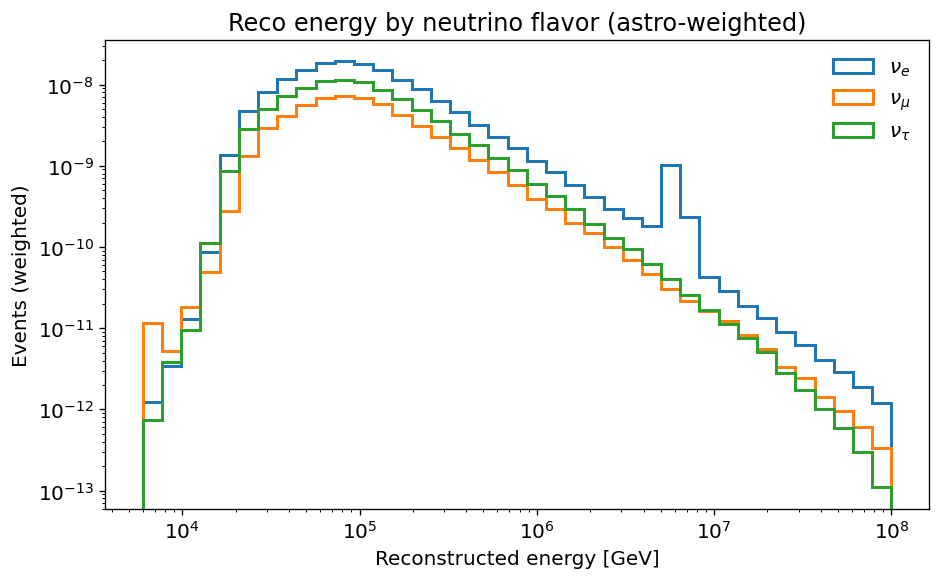

In [17]:
energy_bins = np.logspace(np.log10(6e3), np.log10(1e8), 40)

fig, ax = make_histogram(
    df,
    variable="reco_energy",
    bins=energy_bins,
    cuts=flavor_cuts,
    cut_labels=flavor_labels,
    xlabel="Reconstructed energy [GeV]",
    title="Reco energy by neutrino flavor (astro-weighted)",
    log_x=True,
)
plt.show()

## Reco length — split by neutrino flavor

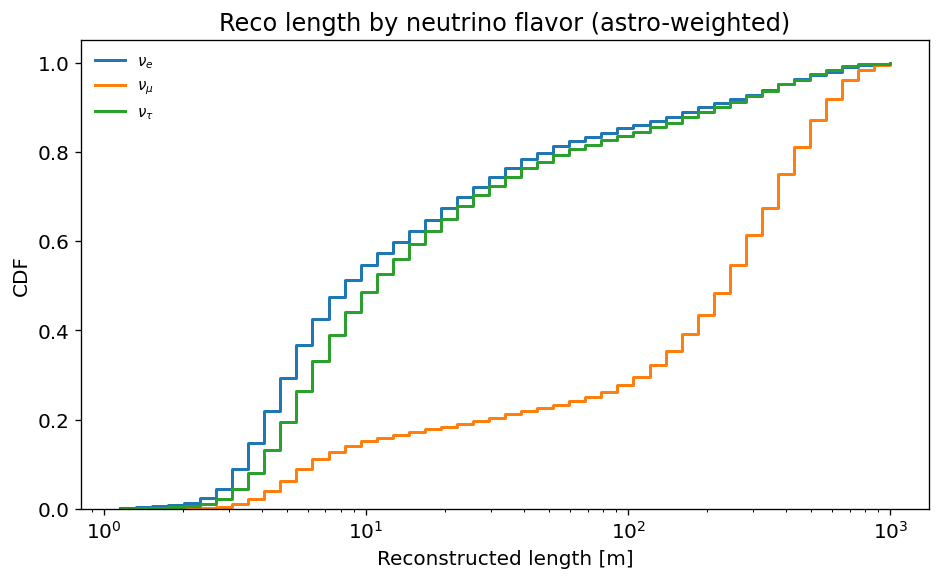

In [16]:
length_bins = np.geomspace(1e0, 1e3, 50)

fig, ax = make_histogram(
    df,
    variable="reco_length",
    bins=length_bins,
    cuts=flavor_cuts,
    cut_labels=flavor_labels,
    xlabel="Reconstructed length [m]",
    title="Reco length by neutrino flavor (astro-weighted)",
    log_x=True,
    cdf=True,
)
plt.show()

## MC primary energy — split by neutrino flavor

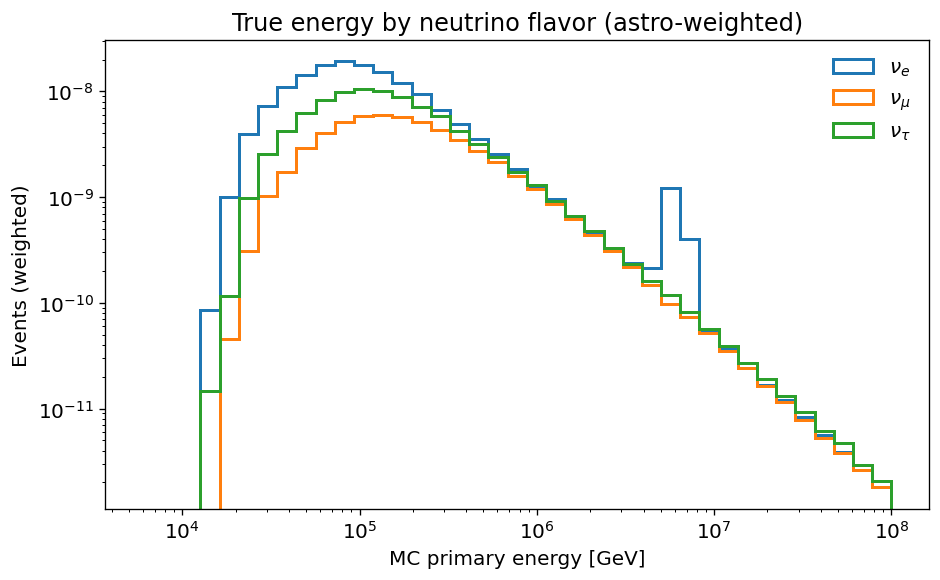

In [19]:
fig, ax = make_histogram(
    df,
    variable="MCPrimaryEnergy",
    bins=energy_bins,
    cuts=flavor_cuts,
    cut_labels=flavor_labels,
    xlabel="MC primary energy [GeV]",
    title="True energy by neutrino flavor (astro-weighted)",
    log_x=True,
)
plt.show()

## Reco length: NuE (all) vs NuTau in TrueLength slices

In [17]:
def plot_nue_vs_nutau_truelength(
    df,
    variable="reco_length",
    bins=None,
    tl_edges=None,
    open_end_bin=True,
    **kwargs,
):
    """
    Histogram of `variable` for all NuE events vs NuTau sliced by TrueLength.

    Parameters
    ----------
    df            : DataFrame
    variable      : column to plot on the x-axis (default: "reco_length")
    bins          : bin edges passed to make_histogram
                    (default: np.linspace(0, 100, 50))
    tl_edges      : list of TrueLength bin edges in metres
                    (default: list(range(0, 31, 5)))
    open_end_bin  : if True, add a final NuTau bin for TrueLength >= tl_edges[-1]
    **kwargs      : forwarded to make_histogram; any key overrides the defaults
                    (xlabel, title, legend_title, normalize, log_y,
                    annotate_energy, h0_index, cdf, ...)
    """
    if bins is None:
        bins = np.linspace(0, 100, 50)
    if tl_edges is None:
        tl_edges = list(range(0, 31, 5))

    nue   = abs(df["MCPrimaryType"]) == 12
    nutau = abs(df["MCPrimaryType"]) == 16

    cuts   = [nue]
    labels = [r"$\nu_e$ (all)"]

    for lo, hi in zip(tl_edges[:-1], tl_edges[1:]):
        mask = nutau & (df["TrueLength"] >= lo) & (df["TrueLength"] < hi)
        cuts.append(mask)
        labels.append(rf"$\nu_\tau$  {lo}–{hi} m")

    if open_end_bin:
        mask = nutau & (df["TrueLength"] >= tl_edges[-1])
        cuts.append(mask)
        labels.append(rf"$\nu_\tau$ >{tl_edges[-1]} m")

    hist_kwargs = dict(
        xlabel=variable,
        title=rf"$\nu_e$ vs $\nu_\tau$ TrueLength slices — {variable} (normalized)",
        legend_title="TrueLength slice",
        normalize=True,
        log_y=False,
        annotate_energy="MCPrimaryEnergy",
        h0_index=0,
    )
    hist_kwargs.update(kwargs)

    return make_histogram(
        df,
        variable=variable,
        bins=bins,
        cuts=cuts,
        cut_labels=labels,
        **hist_kwargs,
    )


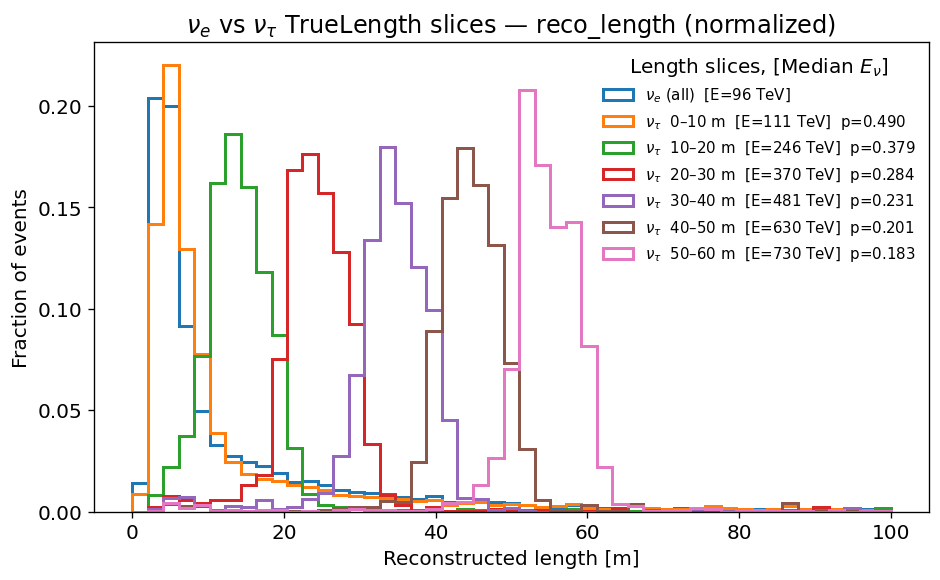

In [24]:
fig, ax = plot_nue_vs_nutau_truelength(
    df,
    variable="reco_length",
    bins=np.linspace(0, 100, 50),
    tl_edges=list(range(0, 61, 10)),
    open_end_bin=False,
    xlabel="Reconstructed length [m]",
    legend_title=r"Length slices, [Median $E_\nu$]",
    annotate_energy="MCPrimaryEnergy",
)
plt.show()


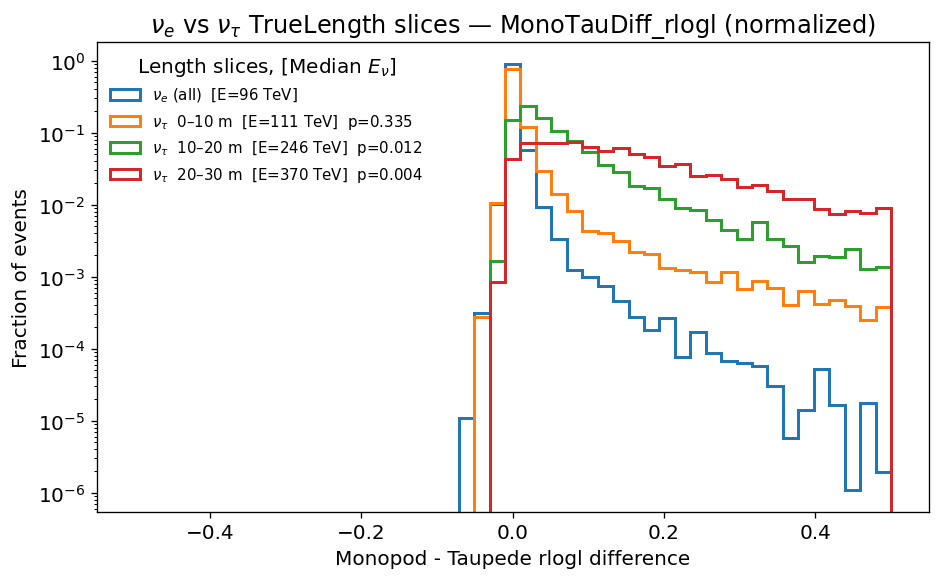

In [58]:
df["MonoTauDiff_rlogl"] = -df["TauMonoDiff_rlogl"]  # flip so higher = more tau-like

fig, ax = plot_nue_vs_nutau_truelength(
    df,
    variable="MonoTauDiff_rlogl",
    bins=np.linspace(-0.5, 0.5, 50),
    tl_edges=list(range(0, 31, 10)),
    open_end_bin=False,
    xlabel="Monopod - Taupede rlogl difference",
    legend_title=r"Length slices, [Median $E_\nu$]",
    annotate_energy="MCPrimaryEnergy",
    log_y = True,
    h0_index=0,
)
plt.show()

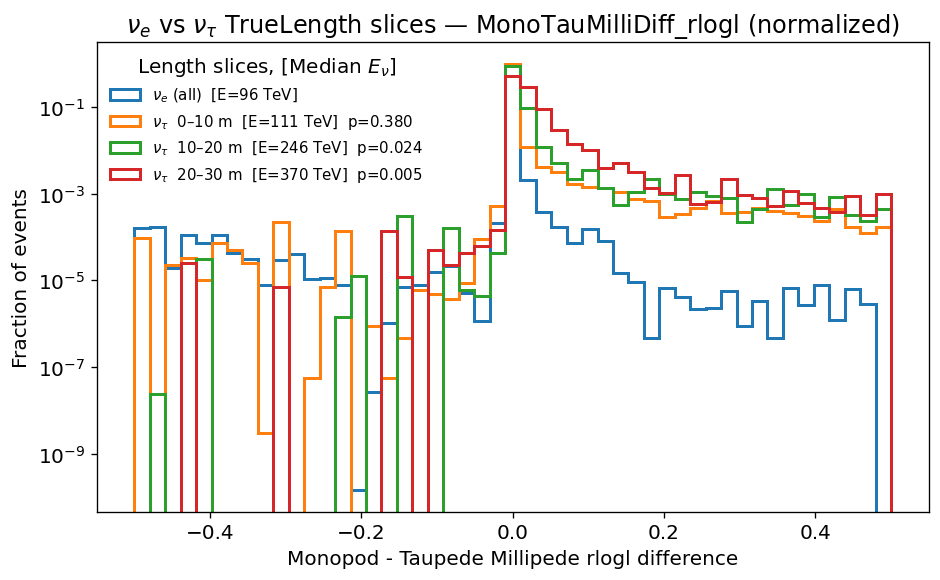

In [60]:
df["MonoTauMilliDiff_rlogl"] = -df["TauMonoMilliDiff_rlogl"]  # flip so higher = more tau-like

fig, ax = plot_nue_vs_nutau_truelength(
    df,
    variable="MonoTauMilliDiff_rlogl",
    bins=np.linspace(-0.5, 0.5, 50),
    tl_edges=list(range(0, 31, 10)),
    open_end_bin=False,
    xlabel="Monopod - Taupede Millipede rlogl difference",
    legend_title=r"Length slices, [Median $E_\nu$]",
    annotate_energy="MCPrimaryEnergy",
    log_y = True,
)
plt.show()

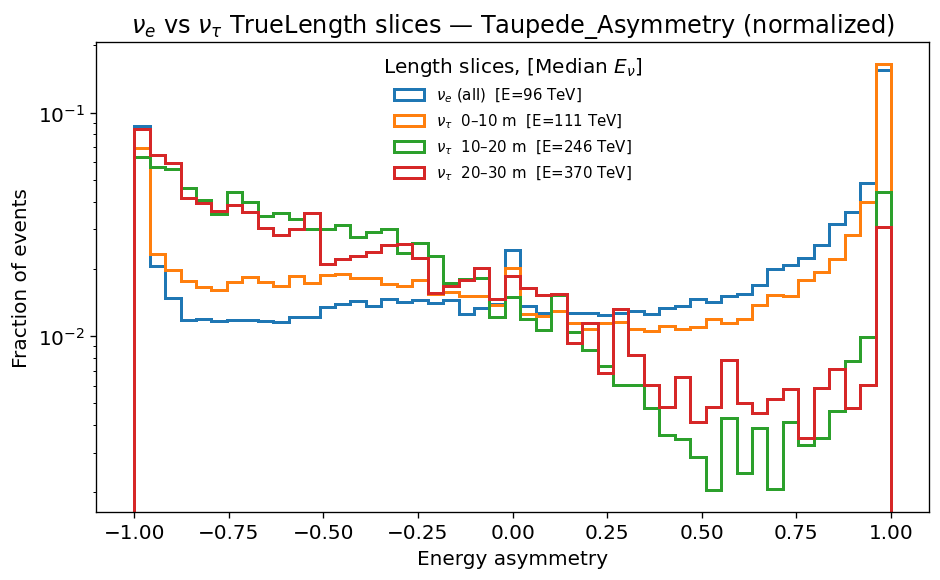

In [61]:
fig, ax = plot_nue_vs_nutau_truelength(
    df,
    variable="Taupede_Asymmetry",
    bins=np.linspace(-1, 1, 50),
    tl_edges=list(range(0, 31, 10)),
    open_end_bin=False,
    xlabel="Energy asymmetry",
    legend_title=r"Length slices, [Median $E_\nu$]",
    annotate_energy="MCPrimaryEnergy",
    log_y = True,
    h0_index=None,
)
plt.show()